## Generación de Conjunto de datos con fallas trifasicas de la A - G

In [1]:
import numpy as np
import pandas as pd
import os
import random
import time

# ==============================================================================
# 1. PARÁMETROS DE CONFIGURACIÓN
# ==============================================================================
# Parámetros de la señal
FS = 7200
FREQ = 60
AMPLITUDE = 1.0
DURATION = 1

# Parámetros del dataset
N_SAMPLES_PER_CLASS = 4100
# --- AJUSTE SOLICITADO ---
N_NOISY = 1100
N_CLEAN = 3000 # 4100 - 1100
# ---
SNR_DB_RANGE = (25, 40)

# Nombre del archivo de salida
OUTPUT_PARQUET_FILE = "Dataset_Trifasico_Bollen_Completo.parquet"

# ==============================================================================
# 2. FUNCIONES AUXILIARES
# ==============================================================================

def generar_señal_trifasica_base(duration=DURATION, fs=FS, freq=FREQ, amplitude=AMPLITUDE):
    """Genera las tres fases de una señal senoidal pura y balanceada."""
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    phase_a = amplitude * np.sin(2 * np.pi * freq * t)
    phase_b = amplitude * np.sin(2 * np.pi * freq * t - 2 * np.pi / 3)
    phase_c = amplitude * np.sin(2 * np.pi * freq * t + 2 * np.pi / 3)
    return t, phase_a, phase_b, phase_c

def añadir_ruido_snr(signal, snr_db):
    """Añade ruido gaussiano a una señal para alcanzar un SNR específico."""
    signal_power = np.mean(signal**2)
    snr_linear = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise

def generar_evento_sag_trifasico_Bollen(t, sag_type, freq=FREQ, amplitude=AMPLITUDE):
    """
    Genera un evento de sag según la clasificación de Bollen, incluyendo
    magnitud y saltos de fase para diferenciar las clases.
    """
    duration_cycles = random.uniform(2, 15)
    sag_duration_s = duration_cycles / freq
    start_time = random.uniform(0.05, DURATION - sag_duration_s - 0.05)
    end_time = start_time + sag_duration_s
    u = (t >= start_time) & (t < end_time)

    # Señales base (se modificarán solo en el intervalo del sag)
    va_sag = amplitude * np.sin(2 * np.pi * freq * t)
    vb_sag = amplitude * np.sin(2 * np.pi * freq * t - 2 * np.pi / 3)
    vc_sag = amplitude * np.sin(2 * np.pi * freq * t + 2 * np.pi / 3)
    
    phase_a_base, phase_b_base, phase_c_base = 0, -2*np.pi/3, 2*np.pi/3

    if sag_type == 'A': # Trifásico balanceado
        depth = random.uniform(0.1, 0.9)
        # No hay salto de fase en sags balanceados
        va_sag[u] *= (1 - depth)
        vb_sag[u] *= (1 - depth)
        vc_sag[u] *= (1 - depth)

    elif sag_type == 'B': # Monofásico en Fase A
        depth = random.uniform(0.1, 0.9)
        phase_jump = random.uniform(-np.pi/10, np.pi/10)
        va_sag[u] = amplitude * (1 - depth) * np.sin(2*np.pi*freq*t[u] + phase_a_base + phase_jump)

    elif sag_type == 'C': # Bifásico en B-C (falla L-L)
        depth = random.uniform(0.1, 0.9)
        phase_jump = random.uniform(-np.pi/8, np.pi/8) # Saltos de fase simétricos
        vb_sag[u] = amplitude * (1 - depth) * np.sin(2*np.pi*freq*t[u] + phase_b_base + phase_jump)
        vc_sag[u] = amplitude * (1 - depth) * np.sin(2*np.pi*freq*t[u] + phase_c_base - phase_jump)

    elif sag_type == 'D': # Bifásico no balanceado en B-C (falla L-L-G)
        depth_b, depth_c = random.uniform(0.1, 0.9), random.uniform(0.1, 0.9)
        phase_jump_b = random.uniform(-np.pi/6, np.pi/6) # Saltos de fase independientes
        phase_jump_c = random.uniform(-np.pi/6, np.pi/6)
        vb_sag[u] = amplitude * (1 - depth_b) * np.sin(2*np.pi*freq*t[u] + phase_b_base + phase_jump_b)
        vc_sag[u] = amplitude * (1 - depth_c) * np.sin(2*np.pi*freq*t[u] + phase_c_base + phase_jump_c)

    elif sag_type == 'E': # Bifásico balanceado en B-C (caso especial)
        depth = random.uniform(0.4, 0.6) # Profundidad controlada
        phase_jump = random.uniform(-np.pi/12, np.pi/12) # Salto de fase pequeño
        vb_sag[u] = amplitude * (1 - depth) * np.sin(2*np.pi*freq*t[u] + phase_b_base + phase_jump)
        vc_sag[u] = amplitude * (1 - depth) * np.sin(2*np.pi*freq*t[u] + phase_c_base + phase_jump)

    elif sag_type == 'F': # Monofásico en Fase B
        depth = random.uniform(0.1, 0.9)
        phase_jump = random.uniform(-np.pi/10, np.pi/10)
        vb_sag[u] = amplitude * (1 - depth) * np.sin(2*np.pi*freq*t[u] + phase_b_base + phase_jump)

    elif sag_type == 'G': # Monofásico en Fase C
        depth = random.uniform(0.1, 0.9)
        phase_jump = random.uniform(-np.pi/10, np.pi/10)
        vc_sag[u] = amplitude * (1 - depth) * np.sin(2*np.pi*freq*t[u] + phase_c_base + phase_jump)

    return va_sag, vb_sag, vc_sag

# ==============================================================================
# 3. BUCLE PRINCIPAL DE GENERACIÓN
# ==============================================================================
if __name__ == "__main__":
    start_total_time = time.time()
    clases_de_fallas = ['Normal', 'Sag_A', 'Sag_B', 'Sag_C', 'Sag_D', 'Sag_E', 'Sag_F', 'Sag_G']
    
    all_signals_data = []

    for clase in clases_de_fallas:
        print(f"--- Generando clase: {clase} ---")
        
        for i in range(1, N_SAMPLES_PER_CLASS + 1):
            t, va_base, vb_base, vc_base = generar_señal_trifasica_base()
            
            if clase != 'Normal':
                sag_type = clase.split('_')[1]
                va, vb, vc = generar_evento_sag_trifasico_Bollen(t, sag_type)
            else:
                va, vb, vc = va_base, vb_base, vc_base
            
            # La lógica de ruido ahora usa N_NOISY = 1100
            is_noisy = i <= N_NOISY
            
            if is_noisy:
                snr = random.uniform(SNR_DB_RANGE[0], SNR_DB_RANGE[1])
                va = añadir_ruido_snr(va, snr)
                vb = añadir_ruido_snr(vb, snr)
                vc = añadir_ruido_snr(vc, snr)
                signal_id = f"{clase}_noisy_{i:04d}"
            else:
                # El contador para clean empieza después de las ruidosas
                signal_id = f"{clase}_clean_{i - N_NOISY:04d}"

            # Crear DataFrame para esta señal
            signal_df = pd.DataFrame({
                'signal_id': np.full(len(t), signal_id, dtype=object),
                'etiqueta': np.full(len(t), clase, dtype=object),
                'timestamp': t,
                'Phase_A': va,
                'Phase_B': vb,
                'Phase_C': vc
            })
            all_signals_data.append(signal_df)

            if i % 500 == 0:
                print(f"   Generadas {i}/{N_SAMPLES_PER_CLASS} señales para la clase {clase}...")

    print("\nConcatenando todos los DataFrames. Esto puede tardar un momento...")
    final_df = pd.concat(all_signals_data, ignore_index=True)
    
    print(f"Guardando el dataset final en {OUTPUT_PARQUET_FILE}...")
    final_df.to_parquet(OUTPUT_PARQUET_FILE, index=False, engine='pyarrow')
    
    end_total_time = time.time()
    print(f"\n¡Generación del dataset completada en {(end_total_time - start_total_time) / 60:.2f} minutos!")

--- Generando clase: Normal ---
   Generadas 500/4100 señales para la clase Normal...
   Generadas 1000/4100 señales para la clase Normal...
   Generadas 1500/4100 señales para la clase Normal...
   Generadas 2000/4100 señales para la clase Normal...
   Generadas 2500/4100 señales para la clase Normal...
   Generadas 3000/4100 señales para la clase Normal...
   Generadas 3500/4100 señales para la clase Normal...
   Generadas 4000/4100 señales para la clase Normal...
--- Generando clase: Sag_A ---
   Generadas 500/4100 señales para la clase Sag_A...
   Generadas 1000/4100 señales para la clase Sag_A...
   Generadas 1500/4100 señales para la clase Sag_A...
   Generadas 2000/4100 señales para la clase Sag_A...
   Generadas 2500/4100 señales para la clase Sag_A...
   Generadas 3000/4100 señales para la clase Sag_A...
   Generadas 3500/4100 señales para la clase Sag_A...
   Generadas 4000/4100 señales para la clase Sag_A...
--- Generando clase: Sag_B ---
   Generadas 500/4100 señales para l

## Visualizar algunos metadatos

In [26]:
import pandas as pd
import pyarrow.parquet as pq
from collections import defaultdict

# 1.  ruta archivo Parquet
file_path = "Dataset_Trifasico_Completo_2.parquet"

# 2. Número de ejemplos a ver por cada clase
EXAMPLES_PER_CLASS = 3

try:
    print(f"Abriendo el archivo: {file_path}...")
    parquet_file = pq.ParquetFile(file_path)

    # Diccionario para guardar los ejemplos encontrados
    class_examples = defaultdict(set)
    # Contadores
    total_signals = set()
    
    print("Analizando el archivo para encontrar señales y clases...")
    # 3. Itera sobre los trozos del archivo (row groups)
    for i in range(parquet_file.num_row_groups):
        # Lee solo las columnas necesarias de cada trozo
        group_table = parquet_file.read_row_group(i, columns=['signal_id', 'etiqueta'])
        group_df = group_table.to_pandas()

        # Agrupa por clase y encuentra los IDs únicos en este trozo
        for clase, data in group_df.groupby('etiqueta'):
            # Añade los IDs únicos al contador total
            total_signals.update(data['signal_id'].unique())
            
            # Si aún no tenemos suficientes ejemplos para esta clase, los añadimos
            if len(class_examples[clase]) < EXAMPLES_PER_CLASS:
                # Toma hasta 3 IDs únicos de este trozo
                ids_to_add = data['signal_id'].unique()[:EXAMPLES_PER_CLASS]
                class_examples[clase].update(ids_to_add)

        # Opcional: Si ya encontramos ejemplos para las 8 clases, podemos parar
        if len(class_examples) == 8:
             # Continuamos leyendo para obtener el conteo total, pero no más ejemplos
             pass


    # 4. Imprime los resultados
    print("\n--- Resumen del Contenido del Dataset ---")
    print(f"Total de clases únicas encontradas: {len(class_examples)}")
    print(f"Total de señales únicas encontradas: {len(total_signals)} (deberían ser 32800)")

    print("\n--- Ejemplos de 'signal_id' por cada clase ---")
    for clase in sorted(class_examples.keys()):
        print(f"\nClase: {clase}")
        # Toma los primeros N ejemplos de la lista para esta clase
        examples_to_show = list(class_examples[clase])[:EXAMPLES_PER_CLASS]
        for signal_id in examples_to_show:
            print(f"  - {signal_id}")

except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta: {file_path}")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")

Abriendo el archivo: Dataset_Trifasico_Completo_2.parquet...
Analizando el archivo para encontrar señales y clases...

--- Resumen del Contenido del Dataset ---
Total de clases únicas encontradas: 8
Total de señales únicas encontradas: 32800 (deberían ser 16000)

--- Ejemplos de 'signal_id' por cada clase ---

Clase: Normal
  - Normal_noisy_0003
  - Normal_noisy_0002
  - Normal_noisy_0001

Clase: Sag_A
  - Sag_A_noisy_0002
  - Sag_A_noisy_0001
  - Sag_A_noisy_0003

Clase: Sag_B
  - Sag_B_noisy_0001
  - Sag_B_noisy_0003
  - Sag_B_noisy_0002

Clase: Sag_C
  - Sag_C_noisy_0002
  - Sag_C_noisy_0001
  - Sag_C_noisy_0003

Clase: Sag_D
  - Sag_D_noisy_0002
  - Sag_D_noisy_0001
  - Sag_D_noisy_0003

Clase: Sag_E
  - Sag_E_noisy_0003
  - Sag_E_noisy_0001
  - Sag_E_noisy_0002

Clase: Sag_F
  - Sag_F_noisy_0003
  - Sag_F_noisy_0001
  - Sag_F_noisy_0002

Clase: Sag_G
  - Sag_G_noisy_0001
  - Sag_G_noisy_0003
  - Sag_G_noisy_0002


## Graficas de Señales Trifasicas

Cargando el dataset desde: C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_Bollen_Completo.parquet...
Buscando y graficando la señal con ID: Normal_clean_2158...


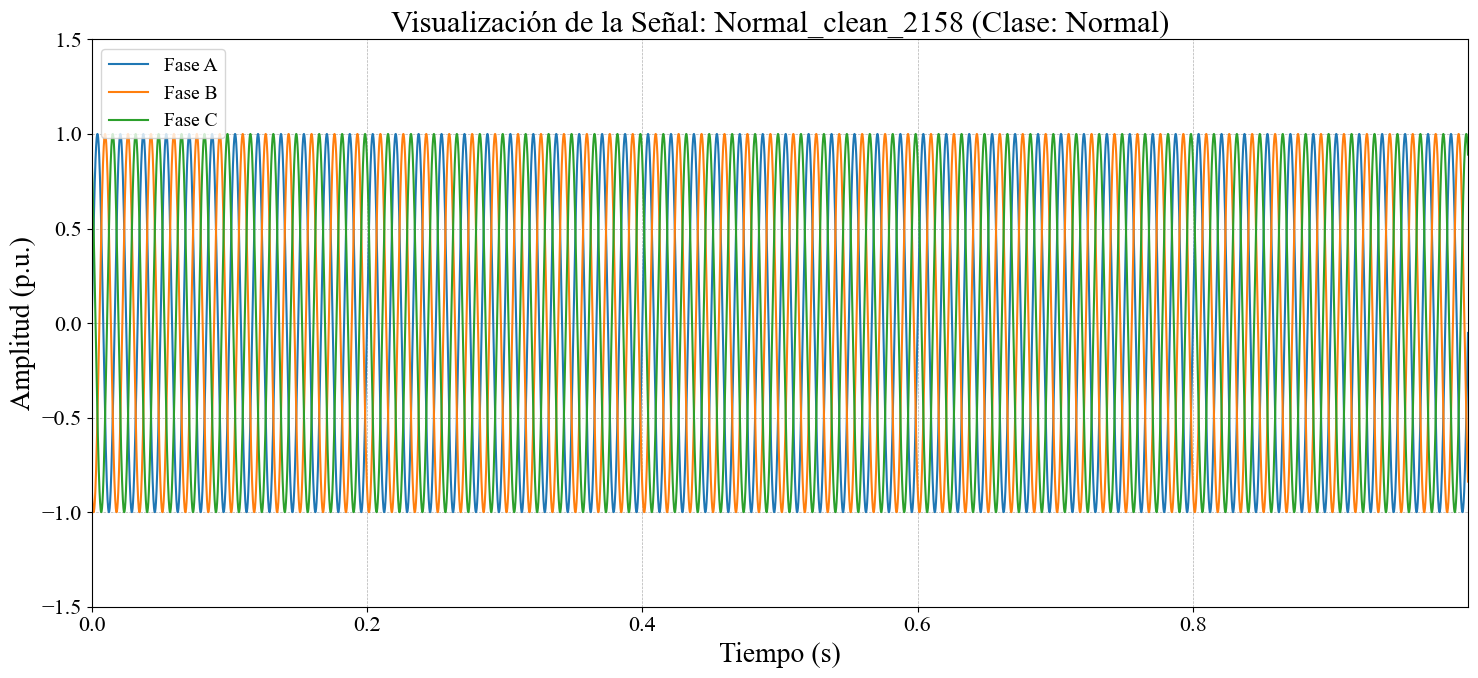

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def _setup_academic_style():
    """Configura los parámetros de Matplotlib para un estilo tipo IEEE."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.labelsize'] = 20
    plt.rcParams['axes.titlesize'] = 22
    plt.rcParams['xtick.labelsize'] = 16 # Ajustado para mejor legibilidad
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams['legend.fontsize'] = 14 # Ajustado para el tamaño de la leyenda
    plt.rcParams['lines.linewidth'] = 1.5
    # El tamaño de la figura se definirá en la función de ploteo para mayor flexibilidad

def plot_signal_by_id(file_path, signal_id):
    """
    Carga un dataset de señales y grafica un evento específico por su ID.
    """
    print(f"Cargando el dataset desde: {file_path}...")
    try:
        if file_path.endswith('.parquet'):
            df = pd.read_parquet(file_path)
        else:
            df = pd.read_csv(file_path)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo en la ruta: {file_path}")
        return
        
    print(f"Buscando y graficando la señal con ID: {signal_id}...")
    
    signal_df = df[df['signal_id'] == signal_id].copy()
    
    if signal_df.empty:
        print(f"Error: No se encontró la señal con el ID '{signal_id}'.")
        return

    etiqueta = signal_df['etiqueta'].iloc[0]

    # --- Creación del Gráfico ---
    # Se usa un tamaño de figura más panorámico, ideal para series de tiempo
    plt.figure(figsize=(15, 7))
    
    plt.plot(signal_df['timestamp'], signal_df['Phase_A'], label='Fase A')
    plt.plot(signal_df['timestamp'], signal_df['Phase_B'], label='Fase B')
    plt.plot(signal_df['timestamp'], signal_df['Phase_C'], label='Fase C')
    
    # Los tamaños de fuente ahora son controlados por rcParams
    plt.title(f'Visualización de la Señal: {signal_id} (Clase: {etiqueta})')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud (p.u.)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xlim(0, max(signal_df['timestamp']))
    plt.ylim(-1.5, 1.5)
    plt.tight_layout() # Ajusta el layout para que no se corten las etiquetas
    plt.show()

# ==============================================================================
# --- ÁREA DE EJECUCIÓN ---
# ==============================================================================
if __name__ == "__main__":
    
    # 1. Aplicamos el estilo académico a todos los gráficos generados
    _setup_academic_style()

    # 2. Define la ruta a tu archivo de dataset
    DATASET_PATH = "Dataset_Trifasico_Completo.parquet"

    # 3. Elige el ID de la señal que quieres graficar
    id_a_graficar = "Sag_C_clean_0003" ## Sag_A_noisy_1000 para ruido y Sag_A_clean_1000 sin ruido
    
    # 4. Llama a la función para graficar
    plot_signal_by_id(DATASET_PATH, id_a_graficar)